# Decision Trees & Random Forests — PyTorch (GPU-Accelerated)

GPU-accelerated Decision Tree and Random Forest using a **hybrid CPU/GPU approach**: tree structure lives as Python dicts on CPU (recursive by nature), but the computationally expensive **split search** runs on GPU via `torch.sort` + `torch.cumsum`. This vectorizes the sorted-scan algorithm — instead of a Python loop over every threshold, all candidate splits are evaluated simultaneously in a single GPU pass per feature.

## Pipeline Structure
- **Part 1: Decision Tree** — GPU-accelerated split search, depth analysis sweep, unrestricted tree baseline
- **Part 2: Random Forest** — Bootstrap aggregation with GPU split search, 100 trees with random feature subsets
- **Showcase: GPU vs CPU Split Search** — Same `find_best_split_gpu()` function benchmarked on CUDA vs CPU tensors

## Dataset
Bank Marketing (UCI) — 41,188 samples, 19 features, binary classification (88.7/11.3 class imbalance).

## Key PyTorch Operations
| Operation | PyTorch Function | Replaces |
|-----------|-----------------|----------|
| Sort features for threshold scan | `torch.sort()` | `np.argsort()` |
| Running class counts (left/right) | `torch.cumsum()` | Python for-loop accumulator |
| Vectorized Gini at all thresholds | Tensor arithmetic | Per-threshold Python calculation |
| Best threshold selection | `torch.argmax()` | Python `max()` tracking |
| Bootstrap sampling | `torch.randint()` | `np.random.choice()` |
| Data partitioning | Boolean tensor masking | NumPy boolean indexing |

In [1]:
# Step 1: Imports and configuration
import sys
import os
import time
import pickle
import numpy as np
import torch

# Add project root to path for shared utilities
sys.path.insert(0, os.path.abspath('../..'))
from utils.data_loader import load_processed_data
from utils.performance import track_performance, track_inference, get_model_size
from utils.metrics import evaluate_classifier, print_metrics
from utils.visualization import (plot_confusion_matrix, plot_roc_curve,
                                  plot_feature_importance, plot_calibration_curve,
                                  plot_tree_depth_analysis, plot_forest_convergence)
from utils.results import build_results_dict, save_results, add_result, print_comparison
from utils.tree_utils import compute_feature_importance, flatten_tree

# Configuration
# ============================================================
RANDOM_STATE = 113
FRAMEWORK = 'PyTorch'
DEPTH_VALUES = [2, 3, 5, 7, 10, 15, 20, None]
N_ESTIMATORS = 100
MAX_FEATURES = 'sqrt'    # sqrt(19) ≈ 4 features per split
RESULTS_DIR = 'results'

# Reproducibility
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Device setup
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.manual_seed(RANDOM_STATE)

# Load data and convert to GPU tensors
# ============================================================
X_train, X_test, y_train, y_test, meta = load_processed_data('decision_tree')

# Features as float32 (sufficient for split thresholds), labels as long (for indexing)
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

feature_names = meta['feature_names']
n_features = X_train.shape[1]
n_classes = len(meta['class_names'])

os.makedirs(RESULTS_DIR, exist_ok=True)

# Dataset overview
# ============================================================
print(f"\n{'=' * 60}")
print(f"DATASET: {meta['dataset']}")
print(f"{'=' * 60}")
print(f"  Train: {X_train_t.shape[0]:,} samples, {n_features} features")
print(f"  Test:  {X_test_t.shape[0]:,} samples")
print(f"  Classes: {n_classes} — {meta['class_names']}")

# Class distribution
train_counts = torch.bincount(y_train_t)
print(f"  Train distribution: {train_counts[0].item():,} no ({train_counts[0].item()/len(y_train_t)*100:.1f}%) | "
      f"{train_counts[1].item():,} yes ({train_counts[1].item()/len(y_train_t)*100:.1f}%)")
print(f"  Tensor dtype: {X_train_t.dtype} (features), {y_train_t.dtype} (labels)")
print(f"  Tensor device: {X_train_t.device}")

Device: cuda
GPU: NVIDIA GeForce RTX 4090
VRAM: 25.8 GB

DATASET: Bank Marketing (UCI)
  Train: 32,950 samples, 19 features
  Test:  8,238 samples
  Classes: 2 — ['no', 'yes']
  Train distribution: 29,238 no (88.7%) | 3,712 yes (11.3%)
  Tensor dtype: torch.float32 (features), torch.int64 (labels)
  Tensor device: cuda:0


In [2]:
# Step 2: GPU-accelerated split criterion functions

# Balanced class weights + Gini impurity + vectorized split search

def compute_sample_weights(y_t):
    """Compute balanced class weights as per-sample weight tensor.
    
    Formula: weight_k = n_samples / (n_classes * n_samples_k)
    Same as sklearn's class_weight='balanced'.
    
    Args:
        y_t: Label tensor (long) on any device
        
    Returns:
        Tensor of per-sample weights, same device as y_t
    """
    classes, counts = torch.unique(y_t, return_counts=True)
    n_samples = y_t.shape[0]
    n_classes = classes.shape[0]
    
    # Weight per class: n / (n_classes * n_k)
    class_weights = n_samples / (n_classes * counts.float())
    
    # Map to per-sample weights
    sample_weights = class_weights[y_t]
    return sample_weights


def gini_impurity_gpu(y_t, sample_weight_t):
    """Weighted Gini impurity: 1 - sum(p_k^2).
    
    Args:
        y_t: Label tensor (long)
        sample_weight_t: Per-sample weight tensor (float)
        
    Returns:
        Scalar Gini impurity value (float)
    """
    if y_t.shape[0] == 0:
        return 0.0
    
    classes = torch.unique(y_t)
    total_weight = sample_weight_t.sum()
    
    if total_weight == 0:
        return 0.0
    
    sum_sq = 0.0
    for c in classes:
        mask = (y_t == c)
        p_k = sample_weight_t[mask].sum() / total_weight
        sum_sq += p_k.item() ** 2
    
    return 1.0 - sum_sq


def find_best_split_gpu(X_t, y_t, sample_weight_t, feature_indices=None):
    """GPU-accelerated best split search using torch.sort + torch.cumsum.
    
    For each candidate feature:
      1. Sort feature values on GPU (torch.sort)
      2. Reorder labels and weights by sorted order
      3. Compute running left-side weighted class counts (torch.cumsum)
      4. Derive right-side counts = total - left
      5. Compute Gini impurity at ALL thresholds simultaneously
      6. Select threshold with maximum information gain
    
    This replaces the No-Framework's Python for-loop over thresholds
    with a single vectorized pass per feature.
    
    Args:
        X_t: Feature tensor (n_samples, n_features) on GPU
        y_t: Label tensor (n_samples,) on GPU
        sample_weight_t: Per-sample weights (n_samples,) on GPU
        feature_indices: Optional list/tensor of feature indices to consider
                        (used by RF for random feature subsets)
    
    Returns:
        Dict {'feature': int, 'threshold': float, 'gain': float} or None
    """
    n_samples, n_features_total = X_t.shape
    
    if feature_indices is None:
        feature_indices = range(n_features_total)
    
    # Parent impurity (computed once)
    total_weight = sample_weight_t.sum()
    parent_gini = gini_impurity_gpu(y_t, sample_weight_t)
    
    best_gain = 0.0
    best_feature = None
    best_threshold = None
    
    # Precompute total weighted counts per class
    n_classes = int(y_t.max().item()) + 1
    total_class_weights = torch.zeros(n_classes, device=X_t.device)
    for c in range(n_classes):
        total_class_weights[c] = sample_weight_t[y_t == c].sum()
    
    for f in feature_indices:
        # 1. Sort feature values on GPU
        sorted_values, sorted_indices = torch.sort(X_t[:, f])
        
        # 2. Reorder labels and weights by sorted order
        sorted_y = y_t[sorted_indices]
        sorted_w = sample_weight_t[sorted_indices]
        
        # 3. Build per-class weight columns for cumsum
        # One-hot encode sorted labels, multiply by weights
        class_indicators = torch.zeros(n_samples, n_classes, device=X_t.device)
        class_indicators[torch.arange(n_samples, device=X_t.device), sorted_y] = sorted_w
        
        # 4. Cumulative sum gives running left-side class weights at each position
        left_class_weights = torch.cumsum(class_indicators, dim=0)  # (n_samples, n_classes)
        
        # 5. Right-side class weights = total - left
        right_class_weights = total_class_weights.unsqueeze(0) - left_class_weights
        
        # 6. Compute Gini for all split positions simultaneously
        # Split happens BETWEEN positions i and i+1, so we use positions 0..n-2
        # Only consider splits where consecutive values differ (unique boundaries)
        valid_splits = sorted_values[:-1] != sorted_values[1:]
        
        if not valid_splits.any():
            continue  # All values identical for this feature
        
        # Left side: positions 0..i (inclusive) → use left_class_weights[:-1]
        left_w = left_class_weights[:-1]       # (n-1, n_classes)
        right_w = right_class_weights[:-1]     # (n-1, n_classes)
        
        left_total = left_w.sum(dim=1)         # (n-1,)
        right_total = right_w.sum(dim=1)       # (n-1,)
        
        # Avoid division by zero
        left_total_safe = left_total.clamp(min=1e-10)
        right_total_safe = right_total.clamp(min=1e-10)
        
        # Gini = 1 - sum(p_k^2) where p_k = class_weight_k / total_weight
        left_p = left_w / left_total_safe.unsqueeze(1)
        right_p = right_w / right_total_safe.unsqueeze(1)
        
        left_gini = 1.0 - (left_p ** 2).sum(dim=1)    # (n-1,)
        right_gini = 1.0 - (right_p ** 2).sum(dim=1)  # (n-1,)
        
        # Weighted average impurity of children
        total_w = total_weight
        weighted_child_gini = (left_total / total_w) * left_gini + \
                              (right_total / total_w) * right_gini
        
        # Information gain = parent_gini - weighted_child_gini
        gains = parent_gini - weighted_child_gini  # (n-1,)
        
        # Mask out invalid splits (consecutive identical values)
        gains = gains * valid_splits.float()
        
        # Find best threshold for this feature
        best_idx = torch.argmax(gains).item()
        feature_gain = gains[best_idx].item()
        
        if feature_gain > best_gain:
            best_gain = feature_gain
            best_feature = int(f) if not isinstance(f, int) else f
            # Threshold = midpoint between sorted_values[best_idx] and sorted_values[best_idx + 1]
            best_threshold = (sorted_values[best_idx].item() + sorted_values[best_idx + 1].item()) / 2.0 # type: ignore
    
    if best_feature is None:
        return None
    
    return {'feature': best_feature, 'threshold': best_threshold, 'gain': best_gain}

In [3]:
# Quick test
sample_weight_t = compute_sample_weights(y_train_t)
classes, counts = torch.unique(y_train_t, return_counts=True)

print(f"{'=' * 60}")
print(f"SPLIT CRITERION FUNCTIONS — GPU")
print(f"{'=' * 60}")
print(f"  Class 0 weight: {sample_weight_t[y_train_t == 0][0].item():.4f}")
print(f"  Class 1 weight: {sample_weight_t[y_train_t == 1][0].item():.4f}")
print(f"  Weighted Gini (full train): {gini_impurity_gpu(y_train_t, sample_weight_t):.4f}")

# Test split search on full training data
t0 = time.perf_counter()
best = find_best_split_gpu(X_train_t, y_train_t, sample_weight_t)
torch.cuda.synchronize()
split_time = time.perf_counter() - t0

print(f"\n  Best split: {feature_names[best['feature']]} <= {best['threshold']:.4f}")
print(f"  Information gain: {best['gain']:.6f}")
print(f"  Split search time: {split_time:.4f}s (GPU, all 19 features)")

SPLIT CRITERION FUNCTIONS — GPU
  Class 0 weight: 0.5635
  Class 1 weight: 4.4383
  Weighted Gini (full train): 0.5000

  Best split: nr.employed <= 5087.6501
  Information gain: 0.098500
  Split search time: 0.0706s (GPU, all 19 features)


In [4]:
# Step 3: Tree building (GPU split search) + prediction helpers

"""
Recursive tree building with GPU-accelerated split search.
Tree structure is dict-based (CPU) — same format as No-Framework
so tree_utils.py (flatten_tree, compute_feature_importance) works as-is.
"""


def build_tree_gpu(X_t, y_t, sample_weight_t, n_classes, max_depth=None, min_samples_split=2, depth=0):
    """Build a decision tree using GPU-accelerated split search.
    
    Recursive construction: at each node, find_best_split_gpu runs
    torch.sort + torch.cumsum on GPU to evaluate all thresholds
    simultaneously. Data partitioning uses GPU boolean masking.
    
    Args:
        X_t: Feature tensor (n_samples, n_features) on GPU
        y_t: Label tensor (n_samples,) on GPU
        sample_weight_t: Per-sample weights (n_samples,) on GPU
        max_depth: Maximum tree depth (None = unlimited)
        min_samples_split: Minimum samples to attempt a split
        depth: Current depth (internal, starts at 0)
        
    Returns:
        Dict tree node — split nodes have 'feature' key, leaf nodes don't.
        Compatible with tree_utils.py (flatten_tree, compute_feature_importance).
    """
    n_samples = X_t.shape[0]
    
    # Compute weighted class distribution for this node
    value = []
    for c in range(n_classes):
        mask = (y_t == c)
        value.append(sample_weight_t[mask].sum().item())
    
    impurity = gini_impurity_gpu(y_t, sample_weight_t)
    
    # Stopping conditions
    # 1. Pure node (all same class)
    # 2. Hit max depth
    # 3. Too few samples to split
    if (len(torch.unique(y_t)) == 1 or
        (max_depth is not None and depth >= max_depth) or
        n_samples < min_samples_split):
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}
    
    # Find best split on GPU
    best = find_best_split_gpu(X_t, y_t, sample_weight_t)
    
    if best is None or best['gain'] <= 0:
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}
    
    # Partition data on GPU (boolean masking)
    left_mask = X_t[:, best['feature']] <= best['threshold']
    right_mask = ~left_mask
    
    # Safety check: empty partition → make leaf
    if left_mask.sum() == 0 or right_mask.sum() == 0:
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}
    
    # Recurse into children
    left_child = build_tree_gpu(X_t[left_mask], y_t[left_mask],
                                 sample_weight_t[left_mask],
                                 n_classes, max_depth, min_samples_split, depth + 1)
    right_child = build_tree_gpu(X_t[right_mask], y_t[right_mask],
                                  sample_weight_t[right_mask],
                                  n_classes, max_depth, min_samples_split, depth + 1)

    
    return {
        'feature': best['feature'],
        'threshold': best['threshold'],
        'left': left_child,
        'right': right_child,
        'value': value,        # Split nodes also carry value (for flatten_tree)
        'n_samples': n_samples,
        'impurity': impurity
    }


def predict_tree_gpu(flat_gpu, X_t):
    """GPU batch prediction using flattened tree arrays.
    
    All samples start at root (node 0). At each iteration, samples
    at internal nodes are routed left/right based on their feature
    value vs the node's threshold. Continues until all reach leaves.
    
    Same algorithm as tree_utils.predict_batch but using GPU tensors.
    
    Args:
        flat_gpu: Dict of GPU tensors from flatten_tree + tensor conversion:
            'feature_indices': int tensor (n_nodes,)
            'thresholds': float tensor (n_nodes,)
            'left_children': int tensor (n_nodes,)
            'right_children': int tensor (n_nodes,)
            'values': float tensor (n_nodes, n_classes)
        X_t: Feature tensor (n_samples, n_features) on GPU
        
    Returns:
        predictions: int tensor (n_samples,) — predicted class labels
        probabilities: float tensor (n_samples, n_classes)
    """
    n_samples = X_t.shape[0]
    feature_indices = flat_gpu['feature_indices']
    thresholds = flat_gpu['thresholds'].float()  # Ensure float32 for comparison
    left_children = flat_gpu['left_children']
    right_children = flat_gpu['right_children']
    values = flat_gpu['values'].float()
    
    # All samples start at root (node 0)
    node_ids = torch.zeros(n_samples, dtype=torch.long, device=X_t.device)
    
    # Route samples until all reach leaves (feature_index == -1)
    while True:
        # Which samples are still at internal (non-leaf) nodes?
        current_features = feature_indices[node_ids]
        at_internal = current_features != -1
        
        if not at_internal.any():
            break
        
        # Get split info for internal-node samples
        internal_idx = torch.where(at_internal)[0]
        internal_nodes = node_ids[internal_idx]
        feat_idx = feature_indices[internal_nodes]
        thresh = thresholds[internal_nodes]
        
        # Get each sample's value for its current node's split feature
        sample_vals = X_t[internal_idx, feat_idx]
        
        # Route: left if value <= threshold, right otherwise
        go_left = sample_vals <= thresh
        
        # Update node IDs
        node_ids[internal_idx[go_left]] = left_children[internal_nodes[go_left]]
        node_ids[internal_idx[~go_left]] = right_children[internal_nodes[~go_left]]
    
    # All samples at leaf nodes — extract predictions
    leaf_values = values[node_ids]  # (n_samples, n_classes)
    
        # Normalize to probabilities
    row_sums = leaf_values.sum(dim=1, keepdim=True).clamp(min=1e-10)
    probabilities = leaf_values / row_sums
    
    # Clamp to avoid log(0) in log_loss calculation
    probabilities = probabilities.clamp(min=1e-7, max=1 - 1e-7)

    
    # Predicted class = argmax
    predictions = torch.argmax(leaf_values, dim=1)
    
    return predictions, probabilities


def get_tree_depth(node):
    """Get maximum depth of a dict-based tree."""
    if 'feature' not in node:
        return 0
    return 1 + max(get_tree_depth(node['left']), get_tree_depth(node['right']))


def get_n_leaves(node):
    """Count number of leaf nodes in a dict-based tree."""
    if 'feature' not in node:
        return 1
    return get_n_leaves(node['left']) + get_n_leaves(node['right'])

def flat_tree_to_gpu(flat_tree, device):
    """Convert flatten_tree output (numpy) to GPU tensors with correct dtypes.
    
    Int arrays (feature_indices, children) → torch.long (matches node_ids).
    Float arrays (thresholds, values) → torch.float32 (matches X_t).
    """
    gpu = {}
    for k, v in flat_tree.items():
        if v.dtype == np.float64:
            gpu[k] = torch.tensor(v, dtype=torch.float32, device=device)
        else:
            gpu[k] = torch.tensor(v, dtype=torch.long, device=device)
    return gpu

In [5]:
# Quick test — build a small tree (depth 3) and verify prediction
test_tree = build_tree_gpu(X_train_t, y_train_t, sample_weight_t, n_classes, max_depth=3)
print(f"{'=' * 60}")
print(f"TREE BUILDING + PREDICTION — GPU")
print(f"{'=' * 60}")
print(f"  Test tree (depth 3): depth={get_tree_depth(test_tree)}, leaves={get_n_leaves(test_tree)}")
print(f"  Root split: {feature_names[test_tree['feature']]} <= {test_tree['threshold']:.4f}")

# Predict with GPU
flat_test = flatten_tree(test_tree)
flat_test_gpu = flat_tree_to_gpu(flat_test, device)
pred, proba = predict_tree_gpu(flat_test_gpu, X_test_t)
pred_np = pred.cpu().numpy()

from utils.metrics import accuracy
acc = accuracy(y_test, pred_np)
print(f"  Test accuracy (depth 3): {acc:.4f}")
print(f"  Predictions device: {pred.device}")
print(f"  Unique predictions: {torch.unique(pred).cpu().tolist()}")

TREE BUILDING + PREDICTION — GPU
  Test tree (depth 3): depth=3, leaves=8
  Root split: nr.employed <= 5087.6501
  Test accuracy (depth 3): 0.8345
  Predictions device: cuda:0
  Unique predictions: [0, 1]


In [6]:
# Step 4: Part 1 — Decision Tree (unrestricted depth)

"""
Train a single DT with no depth limit to demonstrate overfitting.
GPU-accelerated split search, CPU dict tree, GPU batch prediction.
"""

print(f"{'=' * 60}")
print(f"PART 1: DECISION TREE (UNRESTRICTED)")
print(f"{'=' * 60}")

# Train with GPU-accelerated split search
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

with track_performance(gpu=True) as dt_perf:
    tree = build_tree_gpu(X_train_t, y_train_t, sample_weight_t, n_classes)
    torch.cuda.synchronize()

depth = get_tree_depth(tree)
leaves = get_n_leaves(tree)
print(f"\n  [1/3] Tree built in {dt_perf['time']:.2f}s")
print(f"        Depth: {depth}, Leaves: {leaves:,}")
print(f"        Root split: {feature_names[tree['feature']]} <= {tree['threshold']:.4f}")
print(f"        Peak GPU memory: {dt_perf['gpu_memory']:.2f} MB")

# Flatten tree + convert to GPU tensors for batch prediction
flat_tree = flatten_tree(tree)
flat_gpu = flat_tree_to_gpu(flat_tree, device)
print(f"        Flat tree nodes: {len(flat_tree['feature_indices'])}")

# Predict on train and test
train_pred, train_proba = predict_tree_gpu(flat_gpu, X_train_t)
test_pred, test_proba = predict_tree_gpu(flat_gpu, X_test_t)

# Convert to numpy for metrics
train_pred_np = train_pred.cpu().numpy()
train_proba_np = train_proba[:, 1].cpu().numpy()
test_pred_np = test_pred.cpu().numpy()
test_proba_np = test_proba[:, 1].cpu().numpy()

# Evaluate
print(f"\n  [2/3] Evaluation")
dt_train_metrics = evaluate_classifier(y_train, train_pred_np, train_proba_np)
dt_test_metrics = evaluate_classifier(y_test, test_pred_np, test_proba_np)
print_metrics(dt_train_metrics, dt_test_metrics, title='Decision Tree (Unrestricted)')

# Store for later comparison with RF
print(f"\n  [3/3] Overfitting check")
print(f"        Train accuracy: {dt_train_metrics['accuracy']:.4f}")
print(f"        Test accuracy:  {dt_test_metrics['accuracy']:.4f}")
print(f"        Gap:            {dt_train_metrics['accuracy'] - dt_test_metrics['accuracy']:.4f}")

PART 1: DECISION TREE (UNRESTRICTED)

  [1/3] Tree built in 47.05s
        Depth: 42, Leaves: 5,378
        Root split: nr.employed <= 5087.6501
        Peak GPU memory: 22.58 MB
        Flat tree nodes: 10755

  [2/3] Evaluation

METRICS — Decision Tree (Unrestricted)
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.9940       0.8434
precision                       0.9491       0.3138
recall                          1.0000       0.3287
f1                              0.9739       0.3211
auc                             0.9999       0.6195
log_loss                        0.0128       2.4140
brier_score                     0.0045       0.1549
ece                             0.8858       0.8863

  [3/3] Overfitting check
        Train accuracy: 0.9940
        Test accuracy:  0.8434
        Gap:            0.1506


DEPTH ANALYSIS
  max_depth=   2: train=0.8353, test=0.8344
  max_depth=   3: train=0.8354, test=0.8345
  max_depth=   5: train=0.8154, test=0.8106
  max_depth=   7: train=0.8217, test=0.8126
  max_depth=  10: train=0.8399, test=0.8174
  max_depth=  15: train=0.8794, test=0.8193
  max_depth=  20: train=0.9221, test=0.8195
  max_depth=None: train=0.9940, test=0.8434

  Optimal depth: None (test accuracy: 0.8434)


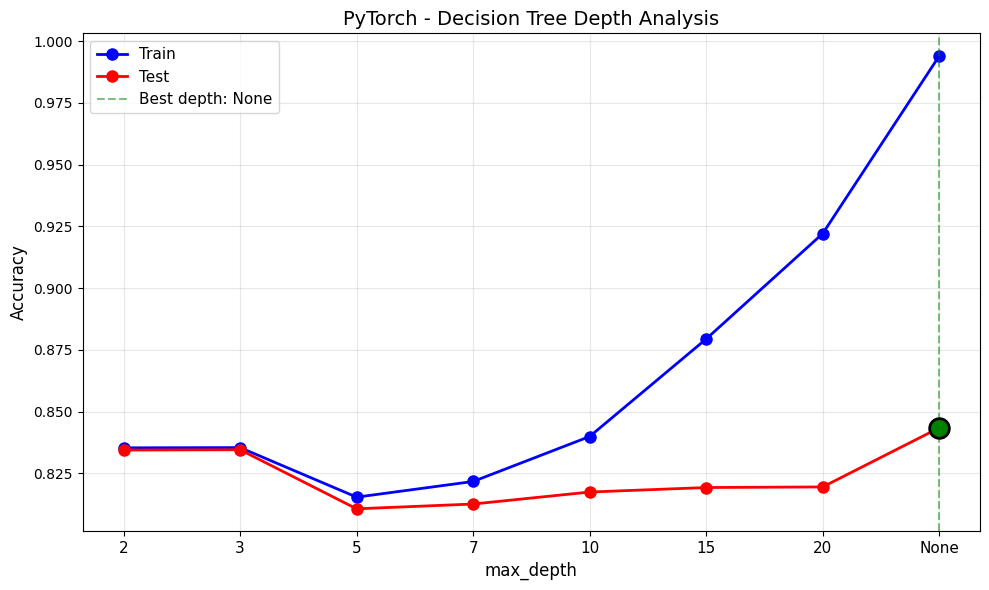

  Saved: results/dt_depth_analysis.png


In [7]:
# Step 5: Depth analysis — train vs test accuracy across max_depth values

"""
Sweep depths to find overfitting point. Reuse unrestricted tree
for max_depth=None to avoid repeating the 47s build.
"""

print(f"{'=' * 60}")
print(f"DEPTH ANALYSIS")
print(f"{'=' * 60}")

train_accs = []
test_accs = []

for d in DEPTH_VALUES:
    if d is None:
        # Reuse the unrestricted tree we already built
        t_acc = dt_train_metrics['accuracy']
        te_acc = dt_test_metrics['accuracy']
    else:
        d_tree = build_tree_gpu(X_train_t, y_train_t, sample_weight_t, n_classes, max_depth=d)
        flat_d = flatten_tree(d_tree)
        flat_d_gpu = flat_tree_to_gpu(flat_d, device)
        
        d_train_pred, _ = predict_tree_gpu(flat_d_gpu, X_train_t)
        d_test_pred, _ = predict_tree_gpu(flat_d_gpu, X_test_t)
        
        t_acc = accuracy(y_train, d_train_pred.cpu().numpy())
        te_acc = accuracy(y_test, d_test_pred.cpu().numpy())
    
    train_accs.append(t_acc)
    test_accs.append(te_acc)
    
    label = str(d) if d is not None else 'None'
    print(f"  max_depth={label:>4}: train={t_acc:.4f}, test={te_acc:.4f}")

# Find optimal depth (best test accuracy)
best_depth_idx = np.argmax(test_accs)
best_depth = DEPTH_VALUES[best_depth_idx]
print(f"\n  Optimal depth: {best_depth} (test accuracy: {test_accs[best_depth_idx]:.4f})")

# Plot depth analysis
plot_tree_depth_analysis(DEPTH_VALUES, train_accs, test_accs,
                          framework=FRAMEWORK,
                          save_path=f'{RESULTS_DIR}/dt_depth_analysis.png')
print(f"  Saved: {RESULTS_DIR}/dt_depth_analysis.png")

DT VISUALIZATIONS


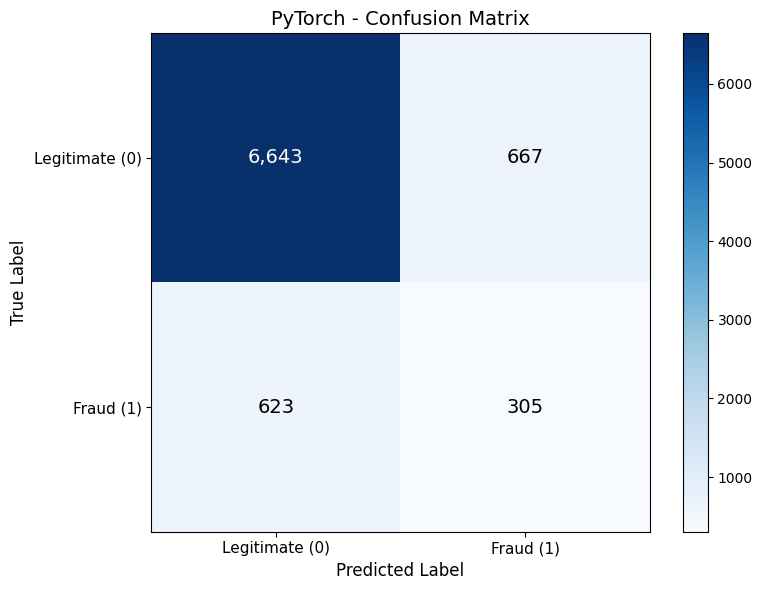

  Saved: results/dt_confusion_matrix.png


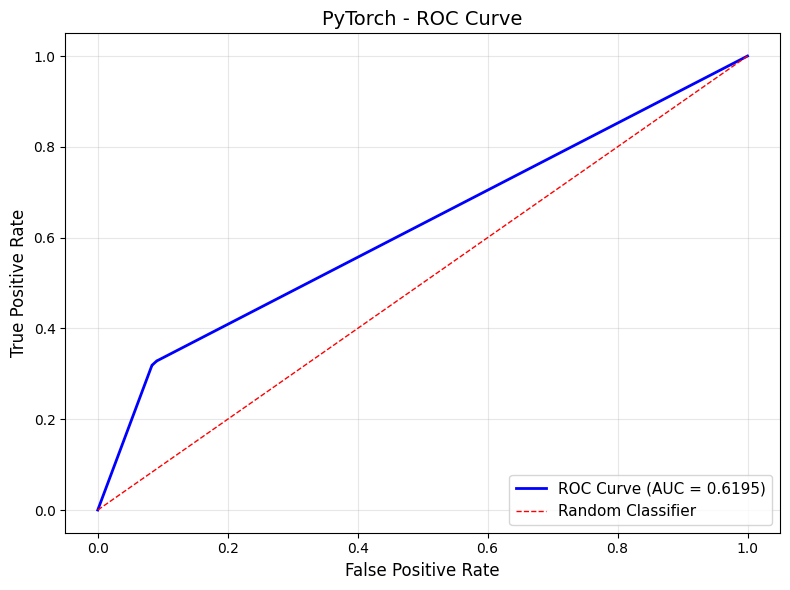

  Saved: results/dt_roc_curve.png


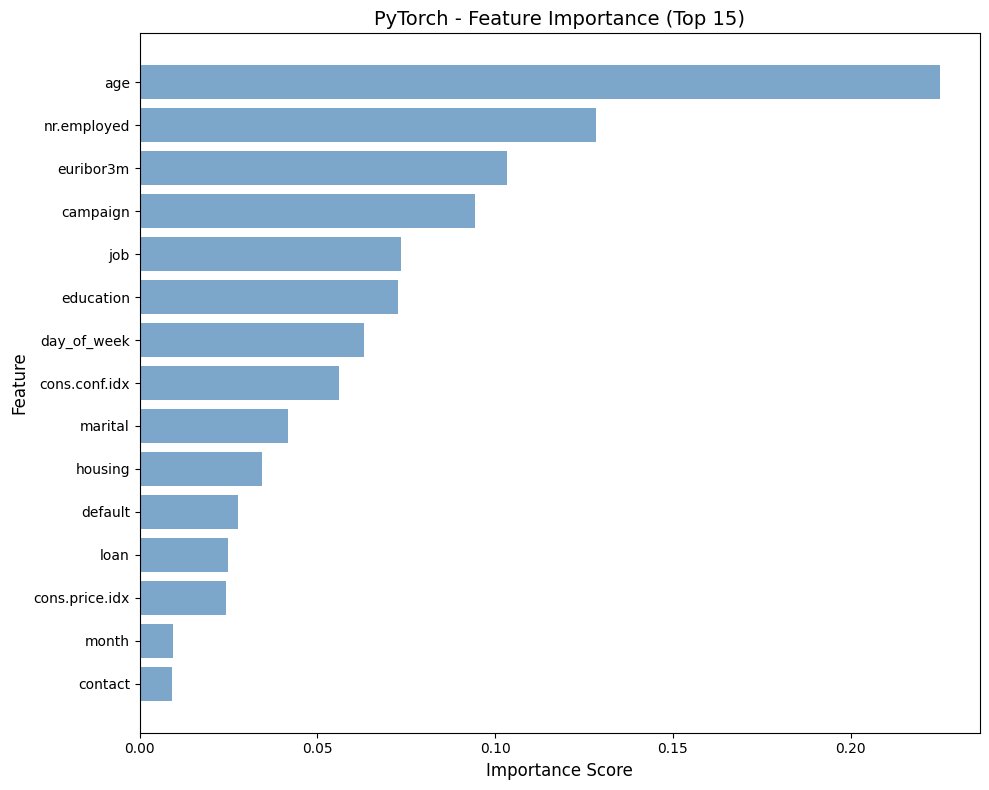

  Saved: results/dt_feature_importance.png
  Top 3: age (0.2251), nr.employed (0.1285), euribor3m (0.1032)


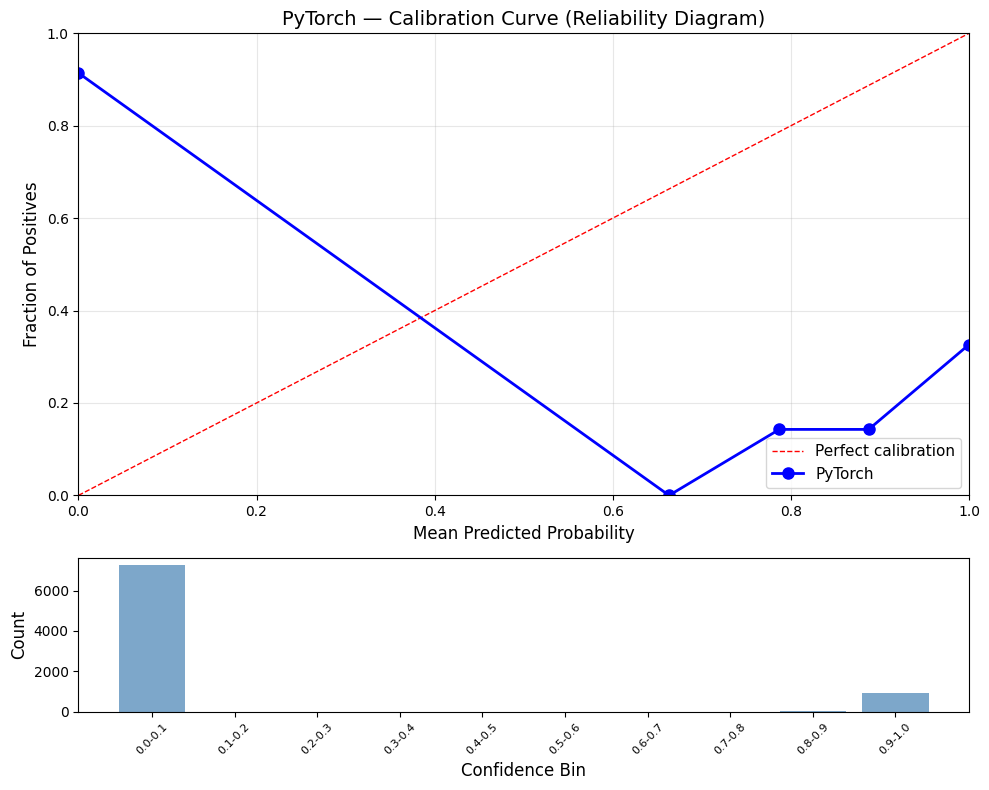

  Saved: results/dt_calibration.png


In [8]:
# Step 6: Decision Tree visualizations

print(f"{'=' * 60}")
print(f"DT VISUALIZATIONS")
print(f"{'=' * 60}")

# Confusion matrix
plot_confusion_matrix(y_test, test_pred_np, framework=FRAMEWORK,
                       save_path=f'{RESULTS_DIR}/dt_confusion_matrix.png')
print(f"  Saved: {RESULTS_DIR}/dt_confusion_matrix.png")

# ROC curve (needs 1D probabilities — already extracted as test_proba_np)
plot_roc_curve(y_test, test_proba_np, framework=FRAMEWORK,
                save_path=f'{RESULTS_DIR}/dt_roc_curve.png')
print(f"  Saved: {RESULTS_DIR}/dt_roc_curve.png")

# Feature importance (from tree_utils, uses dict tree)
dt_importances = compute_feature_importance(tree, n_features)
plot_feature_importance(dt_importances, feature_names, framework=FRAMEWORK,
                         mode='importance',
                         save_path=f'{RESULTS_DIR}/dt_feature_importance.png')
print(f"  Saved: {RESULTS_DIR}/dt_feature_importance.png")
print(f"  Top 3: {', '.join(f'{feature_names[i]} ({dt_importances[i]:.4f})' for i in np.argsort(dt_importances)[::-1][:3])}")

# Calibration curve
plot_calibration_curve(y_test, test_proba_np, framework=FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/dt_calibration.png')
print(f"  Saved: {RESULTS_DIR}/dt_calibration.png")

## Part 2: Random Forest (GPU-Accelerated)

Bootstrap aggregation with GPU-accelerated split search. Each of 100 trees:
1. **Bootstrap sample** — `torch.randint` for sampling with replacement on GPU
2. **Random feature subsets** — `sqrt(19) ≈ 4` random features per split node
3. **GPU split search** — same `find_best_split_gpu` with feature subset restriction

Prediction: average probability distributions across all trees (soft voting).

In [ ]:
# Step 7: Random Forest functions

"""
Bootstrap aggregation with GPU-accelerated split search.
Each tree sees a random bootstrap sample and random feature
subsets at each split node.
"""

def bootstrap_sample_gpu(X_t, y_t, sample_weight_t, seed):
    """
    Generate a bootstrap sample and out-of-bag mask on GPU.
    
    Samples n indices with replacement using torch.randint.
    OOB mask identifies samples NOT selected (for OOB evaluation).
    
    Args:
        X_t: Feature tensor (n_samples, n_features) on GPU
        y_t: Label tensor (n_samples,) on GPU
        sample_weight_t: Per-sample weights (n_samples,) on GPU
        seed: Random seed for this bootstrap (RANDOM_STATE + tree_idx)
        
    Returns:
        X_boot, y_boot, sw_boot: Bootstrap sample tensors
        oob_mask: Boolean tensor (n_samples,) — True for out-of-bag samples
    """
    n = X_t.shape[0]
    gen = torch.Generator(device=X_t.device)
    gen.manual_seed(seed)
    
    # Sample n indices with replacement
    boot_idx = torch.randint(0, n, (n,), device=X_t.device, generator=gen)
    
    # OOB = samples whose index never appeared in boot_idx
    selected = torch.zeros(n, dtype=torch.bool, device=X_t.device)
    selected[boot_idx] = True
    oob_mask = ~selected
    
    return X_t[boot_idx], y_t[boot_idx], sample_weight_t[boot_idx], oob_mask

def build_forest_gpu(X_t, y_t, sample_weight_t, n_classes, n_estimators,
                      max_features='sqrt', max_depth=None):
    """
    Build a Random Forest with GPU-accelerated split search.
    
    Each tree is built on a bootstrap sample with random feature
    subsets (sqrt(n_features)) at each split node. Trees are built
    sequentially — recursion limits true parallelism per tree, but
    each tree's split search is GPU-accelerated.
    
    Args:
        X_t: Feature tensor (n_samples, n_features) on GPU
        y_t: Label tensor (n_samples,) on GPU
        sample_weight_t: Per-sample weights on GPU
        n_classes: Number of classes (passed to build_tree_gpu)
        n_estimators: Number of trees to build
        max_features: 'sqrt' or int — features per split node
        max_depth: Maximum tree depth (None = unlimited)
        
    Returns:
        forest: List of dict trees
        oob_masks: List of boolean numpy arrays (for OOB computation)
    """
    n_features = X_t.shape[1]
    
    # Determine number of features per split
    if max_features == 'sqrt':
        max_f = int(np.sqrt(n_features))
    else:
        max_f = int(max_features)
    
    forest = []
    oob_masks = []
    
    print(f"\n  Building {n_estimators} trees (max_features={max_f})...")
    t0 = time.perf_counter()
    
    for i in range(n_estimators):
        # Bootstrap sample
        X_boot, y_boot, sw_boot, oob_mask = bootstrap_sample_gpu(
            X_t, y_t, sample_weight_t, seed=RANDOM_STATE + i)
        
        # Build tree with random feature subsets
        # We override find_best_split_gpu's feature_indices at each node
        # by passing max_f through a modified build function
        tree_i = build_rf_tree_gpu(X_boot, y_boot, sw_boot, n_classes,
                                    max_f, max_depth)
        
        forest.append(tree_i)
        oob_masks.append(oob_mask.cpu().numpy())
        
        if (i + 1) % 10 == 0:
            elapsed = time.perf_counter() - t0
            per_tree = elapsed / (i + 1)
            remaining = per_tree * (n_estimators - i - 1)
            print(f"    Tree {i+1:3d}/{n_estimators} | "
                  f"{elapsed:.1f}s elapsed | ~{remaining:.0f}s remaining")
    
    total = time.perf_counter() - t0
    print(f"  Forest complete: {total:.1f}s ({total/n_estimators:.2f}s/tree)")
    
    return forest, oob_masks

def build_rf_tree_gpu(X_t, y_t, sample_weight_t, n_classes, max_f,
                       max_depth=None, min_samples_split=2, depth=0):
    """
    Build a single RF tree with per-node random feature subsets.
    
    Same as build_tree_gpu but selects max_f random features at each
    split node (not all n_features). This is the 'random' in Random Forest.
    
    Args:
        X_t, y_t, sample_weight_t: Training data on GPU
        n_classes: Number of classes
        max_f: Number of random features to consider per split
        max_depth: Maximum depth (None = unlimited)
        min_samples_split: Minimum samples to attempt split
        depth: Current depth
        
    Returns:
        Dict tree node (same format as build_tree_gpu)
    """
    n_samples = X_t.shape[0]
    n_features = X_t.shape[1]
    
    # Compute weighted class distribution
    value = []
    for c in range(n_classes):
        mask = (y_t == c)
        value.append(sample_weight_t[mask].sum().item())
    
    impurity = gini_impurity_gpu(y_t, sample_weight_t)
    
    # Stopping conditions
    if (len(torch.unique(y_t)) == 1 or
        (max_depth is not None and depth >= max_depth) or
        n_samples < min_samples_split):
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}
    
    # Random feature subset (the 'random' in Random Forest)
    feature_indices = np.random.choice(n_features, size=max_f, replace=False)
    
    # Find best split using only selected features
    best = find_best_split_gpu(X_t, y_t, sample_weight_t,
                                feature_indices=feature_indices)
    
    if best is None or best['gain'] <= 0:
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}
    
    # Partition data
    left_mask = X_t[:, best['feature']] <= best['threshold']
    right_mask = ~left_mask
    
    if left_mask.sum() == 0 or right_mask.sum() == 0:
        return {'value': value, 'n_samples': n_samples, 'impurity': impurity}
    
    # Recurse
    left_child = build_rf_tree_gpu(X_t[left_mask], y_t[left_mask],
                                    sample_weight_t[left_mask],
                                    n_classes, max_f, max_depth,
                                    min_samples_split, depth + 1)
    right_child = build_rf_tree_gpu(X_t[right_mask], y_t[right_mask],
                                     sample_weight_t[right_mask],
                                     n_classes, max_f, max_depth,
                                     min_samples_split, depth + 1)
    
    return {
        'feature': best['feature'],
        'threshold': best['threshold'],
        'left': left_child,
        'right': right_child,
        'value': value,
        'n_samples': n_samples,
        'impurity': impurity
    }

def predict_forest_gpu(forest, X_t):
    """Predict using all trees in the forest (averaged probabilities).
    
    Flattens each tree, converts to GPU tensors, predicts, then
    averages probabilities across all trees (soft voting).
    
    Args:
        forest: List of dict trees
        X_t: Feature tensor on GPU
        
    Returns:
        predictions: int tensor (n_samples,) — class labels
        probabilities: float tensor (n_samples, n_classes) — averaged probs
    """
    all_probas = []
    
    for tree_i in forest:
        flat_i = flatten_tree(tree_i)
        flat_gpu_i = flat_tree_to_gpu(flat_i, X_t.device)
        _, proba_i = predict_tree_gpu(flat_gpu_i, X_t)
        all_probas.append(proba_i)
    
    # Stack and average: (n_trees, n_samples, n_classes) → (n_samples, n_classes)
    avg_proba = torch.stack(all_probas).mean(dim=0)
    predictions = torch.argmax(avg_proba, dim=1)
    
    return predictions, avg_proba

print(f"{'=' * 60}")
print(f"RANDOM FOREST FUNCTIONS DEFINED")
print(f"{'=' * 60}")
print(f"  build_rf_tree_gpu — per-node random feature subsets")
print(f"  build_forest_gpu — {N_ESTIMATORS} trees with bootstrap + GPU splits")
print(f"  predict_forest_gpu — averaged probability voting")
print(f"  bootstrap_sample_gpu — torch.randint sampling + OOB mask")

RANDOM FOREST FUNCTIONS DEFINED
  build_rf_tree_gpu — per-node random feature subsets
  build_forest_gpu — 100 trees with bootstrap + GPU splits
  predict_forest_gpu — averaged probability voting
  bootstrap_sample_gpu — torch.randint sampling + OOB mask


In [10]:
# Step 8: Part 2 — Random Forest training + evaluation

print(f"{'=' * 60}")
print(f"PART 2: RANDOM FOREST ({N_ESTIMATORS} trees)")
print(f"{'=' * 60}")

# Train forest with GPU-accelerated split search
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

with track_performance(gpu=True) as rf_perf:
    forest, oob_masks = build_forest_gpu(X_train_t, y_train_t, sample_weight_t,
                                          n_classes, N_ESTIMATORS, MAX_FEATURES)
    torch.cuda.synchronize()

print(f"\n  [1/4] Forest trained in {rf_perf['time']:.1f}s "
      f"({rf_perf['time']/60:.1f} min)")
print(f"        Peak GPU memory: {rf_perf['gpu_memory']:.2f} MB")

# Predict on train and test
print(f"\n  [2/4] Predicting...")
rf_train_pred, rf_train_proba = predict_forest_gpu(forest, X_train_t)
rf_test_pred, rf_test_proba = predict_forest_gpu(forest, X_test_t)

# Convert to numpy (extract positive class for binary metrics)
rf_train_pred_np = rf_train_pred.cpu().numpy()
rf_train_proba_np = rf_train_proba[:, 1].cpu().numpy()
rf_test_pred_np = rf_test_pred.cpu().numpy()
rf_test_proba_np = rf_test_proba[:, 1].cpu().numpy()

# Evaluate
print(f"\n  [3/4] Evaluation")
rf_train_metrics = evaluate_classifier(y_train, rf_train_pred_np, rf_train_proba_np)
rf_test_metrics = evaluate_classifier(y_test, rf_test_pred_np, rf_test_proba_np)
print_metrics(rf_train_metrics, rf_test_metrics, title='Random Forest (100 trees)')

# DT vs RF comparison
print(f"\n  [4/4] DT vs RF comparison")
print(f"  {'Metric':<20} {'DT':>10} {'RF':>10} {'Change':>10}")
print(f"  {'-' * 50}")
for metric in ['accuracy', 'f1', 'auc']:
    dt_val = dt_test_metrics[metric]
    rf_val = rf_test_metrics[metric]
    change = rf_val - dt_val
    print(f"  {metric:<20} {dt_val:>10.4f} {rf_val:>10.4f} {change:>+10.4f}")

PART 2: RANDOM FOREST (100 trees)

  Building 100 trees (max_features=4)...
    Tree  10/100 | 152.7s elapsed | ~1374s remaining
    Tree  20/100 | 294.1s elapsed | ~1176s remaining
    Tree  30/100 | 449.2s elapsed | ~1048s remaining
    Tree  40/100 | 592.0s elapsed | ~888s remaining
    Tree  50/100 | 744.4s elapsed | ~744s remaining
    Tree  60/100 | 899.7s elapsed | ~600s remaining
    Tree  70/100 | 1047.0s elapsed | ~449s remaining
    Tree  80/100 | 1184.3s elapsed | ~296s remaining
    Tree  90/100 | 1323.1s elapsed | ~147s remaining
    Tree 100/100 | 1473.0s elapsed | ~0s remaining
  Forest complete: 1473.0s (14.73s/tree)

  [1/4] Forest trained in 1473.0s (24.6 min)
        Peak GPU memory: 25.48 MB

  [2/4] Predicting...

  [3/4] Evaluation

METRICS — Random Forest (100 trees)
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.9758       0.8906
precision                       0.9204      

RF VISUALIZATIONS


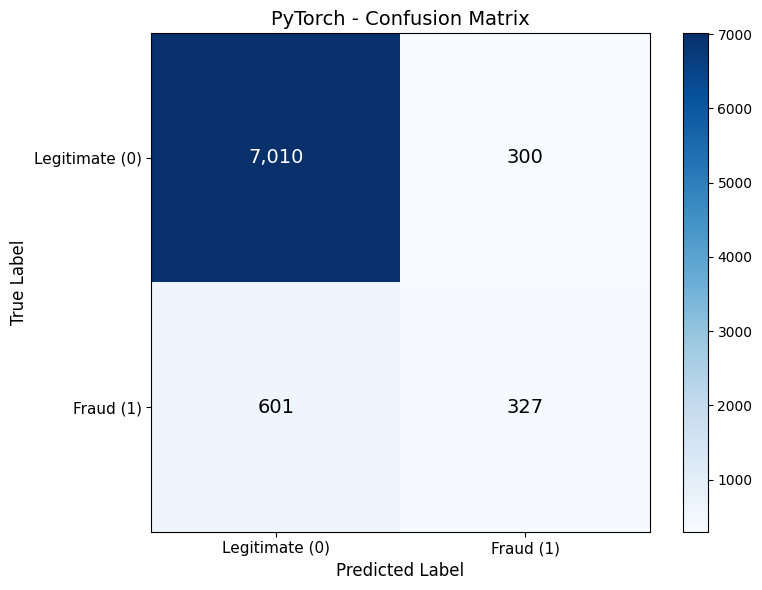

  Saved: results/rf_confusion_matrix.png


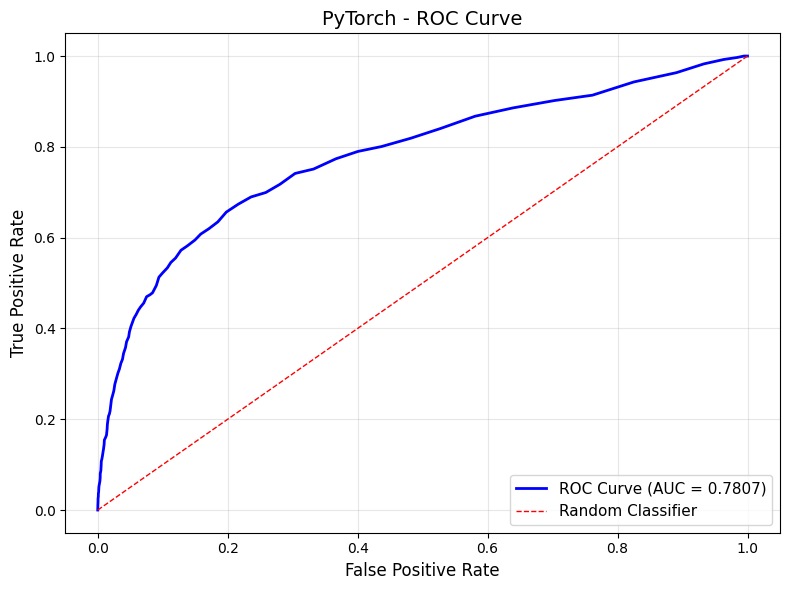

  Saved: results/rf_roc_curve.png


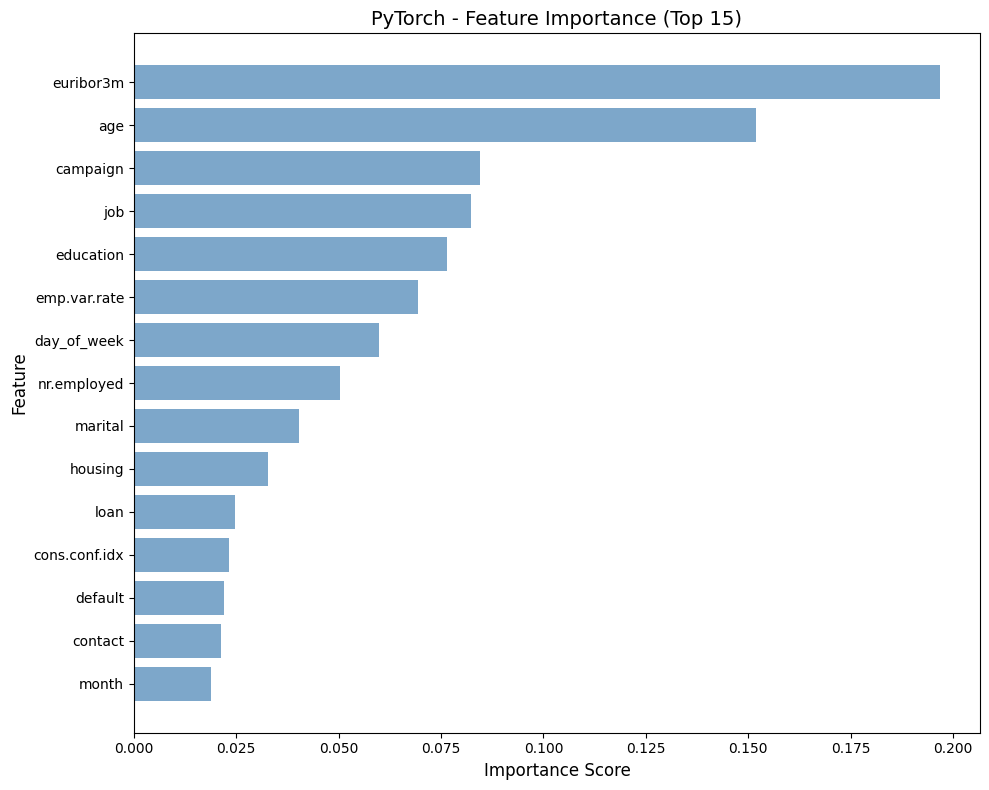

  Saved: results/rf_feature_importance.png
  Top 3: euribor3m (0.1967), age (0.1520), campaign (0.0844)


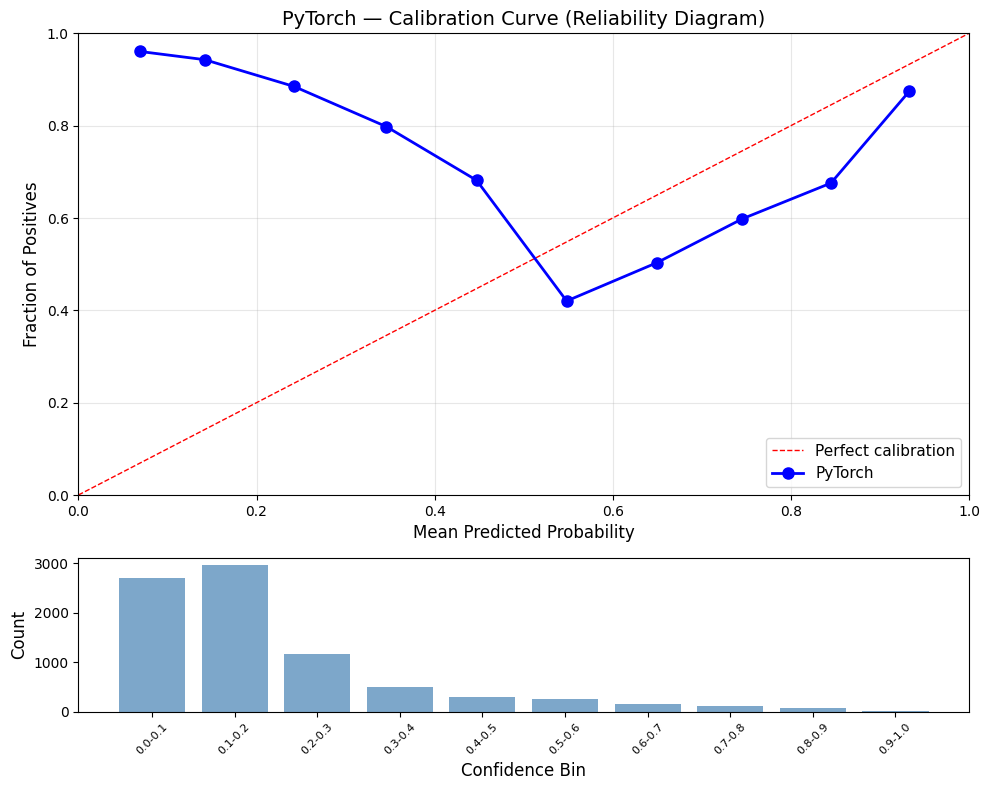

  Saved: results/rf_calibration.png

  Computing forest convergence...


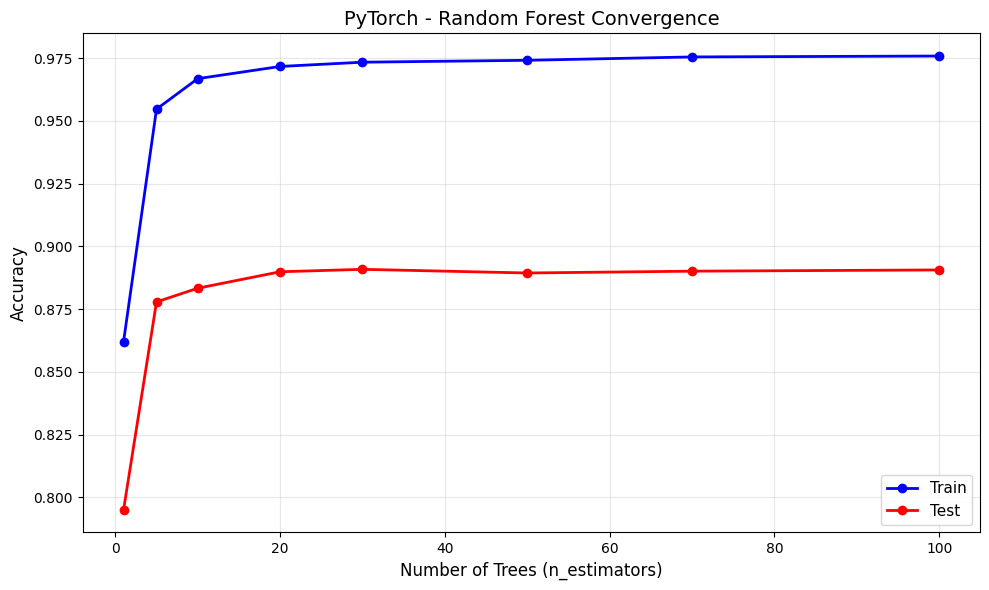

  Saved: results/rf_convergence.png


In [11]:
# Step 9: RF visualizations

print(f"{'=' * 60}")
print(f"RF VISUALIZATIONS")
print(f"{'=' * 60}")

# Confusion matrix
plot_confusion_matrix(y_test, rf_test_pred_np, framework=FRAMEWORK,
                       save_path=f'{RESULTS_DIR}/rf_confusion_matrix.png')
print(f"  Saved: {RESULTS_DIR}/rf_confusion_matrix.png")

# ROC curve
plot_roc_curve(y_test, rf_test_proba_np, framework=FRAMEWORK,
                save_path=f'{RESULTS_DIR}/rf_roc_curve.png')
print(f"  Saved: {RESULTS_DIR}/rf_roc_curve.png")

# Feature importance — average across all trees
rf_importances = np.zeros(n_features)
for tree_i in forest:
    rf_importances += compute_feature_importance(tree_i, n_features)
rf_importances /= len(forest)

plot_feature_importance(rf_importances, feature_names, framework=FRAMEWORK,
                         mode='importance',
                         save_path=f'{RESULTS_DIR}/rf_feature_importance.png')
print(f"  Saved: {RESULTS_DIR}/rf_feature_importance.png")
print(f"  Top 3: {', '.join(f'{feature_names[i]} ({rf_importances[i]:.4f})' for i in np.argsort(rf_importances)[::-1][:3])}")

# Calibration curve
plot_calibration_curve(y_test, rf_test_proba_np, framework=FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/rf_calibration.png')
print(f"  Saved: {RESULTS_DIR}/rf_calibration.png")

# Forest convergence — use subsets of existing forest (no retraining)
n_est_values = [1, 5, 10, 20, 30, 50, 70, 100]
conv_train_accs = []
conv_test_accs = []

print(f"\n  Computing forest convergence...")
for n in n_est_values:
    sub_forest = forest[:n]
    sub_train_pred, _ = predict_forest_gpu(sub_forest, X_train_t)
    sub_test_pred, _ = predict_forest_gpu(sub_forest, X_test_t)
    conv_train_accs.append(accuracy(y_train, sub_train_pred.cpu().numpy()))
    conv_test_accs.append(accuracy(y_test, sub_test_pred.cpu().numpy()))

plot_forest_convergence(n_est_values, conv_train_accs, conv_test_accs,
                         framework=FRAMEWORK,
                         save_path=f'{RESULTS_DIR}/rf_convergence.png')
print(f"  Saved: {RESULTS_DIR}/rf_convergence.png")

In [12]:
# Step 10: Showcase — GPU vs CPU split search benchmark

"""
The key PyTorch innovation: find_best_split_gpu uses torch.sort + torch.cumsum
to evaluate ALL threshold candidates simultaneously. The same function works
on both GPU and CPU tensors — this benchmark measures the speedup from moving
the sort + cumsum operations to the GPU.

Benchmark: run the same split search on the full training set (32,950 × 19)
using CUDA tensors vs CPU tensors, timing N_RUNS iterations after warmup.
"""

N_RUNS = 50

print(f"{'=' * 60}")
print(f"SHOWCASE: GPU vs CPU SPLIT SEARCH")
print(f"{'=' * 60}")
print(f"  Dataset: {X_train_t.shape[0]:,} samples × {X_train_t.shape[1]} features")
print(f"  Benchmark: {N_RUNS} iterations of find_best_split_gpu")

# Move data to CPU tensors (same function, different device)
X_cpu = X_train_t.cpu()
y_cpu = y_train_t.cpu()
sw_cpu = sample_weight_t.cpu()

# Warmup (JIT compilation, cache warming)
print(f"\n  Warmup...")
_ = find_best_split_gpu(X_train_t, y_train_t, sample_weight_t)
torch.cuda.synchronize()
_ = find_best_split_gpu(X_cpu, y_cpu, sw_cpu)

# Benchmark GPU
print(f"  Timing GPU ({N_RUNS} runs)...")
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(N_RUNS):
    _ = find_best_split_gpu(X_train_t, y_train_t, sample_weight_t)
    torch.cuda.synchronize()
gpu_total = time.perf_counter() - t0
gpu_per_split = gpu_total / N_RUNS

# Benchmark CPU
print(f"  Timing CPU ({N_RUNS} runs)...")
t0 = time.perf_counter()
for _ in range(N_RUNS):
    _ = find_best_split_gpu(X_cpu, y_cpu, sw_cpu)
cpu_total = time.perf_counter() - t0
cpu_per_split = cpu_total / N_RUNS

# Results
speedup = cpu_per_split / gpu_per_split

print(f"\n  {'Device':<10} {'Per Split':>12} {'Total ({N_RUNS} runs)':>18}")
print(f"  {'-' * 42}")
print(f"  {'GPU':<10} {gpu_per_split*1000:>10.2f} ms {gpu_total:>15.2f} s")
print(f"  {'CPU':<10} {cpu_per_split*1000:>10.2f} ms {cpu_total:>15.2f} s")
print(f"\n  GPU Speedup: {speedup:.2f}x faster")
print(f"\n  Why it matters:")
print(f"    Each tree requires ~hundreds of split searches (one per internal node).")
print(f"    With {N_ESTIMATORS} trees × ~{get_n_leaves(forest[0])} nodes/tree,")
print(f"    the {speedup:.1f}x per-split speedup compounds across the entire forest.")

SHOWCASE: GPU vs CPU SPLIT SEARCH
  Dataset: 32,950 samples × 19 features
  Benchmark: 50 iterations of find_best_split_gpu

  Warmup...
  Timing GPU (50 runs)...
  Timing CPU (50 runs)...

  Device        Per Split Total ({N_RUNS} runs)
  ------------------------------------------
  GPU             42.09 ms            2.10 s
  CPU             55.30 ms            2.77 s

  GPU Speedup: 1.31x faster

  Why it matters:
    Each tree requires ~hundreds of split searches (one per internal node).
    With 100 trees × ~2939 nodes/tree,
    the 1.3x per-split speedup compounds across the entire forest.


In [14]:
# Step 11: Save results + cross-framework comparison

"""
Package all metrics, performance stats, and inference benchmarks into
standardized format. Save locally and add to cross-framework comparison.

Key detail: forest is a list of Python dicts (not nn.Module), so
get_model_size won't work — use pickle.dumps for model size instead.
"""

print(f"{'=' * 60}")
print(f"SAVE RESULTS + CROSS-FRAMEWORK COMPARISON")
print(f"{'=' * 60}")

# Inference timing
# track_inference expects a callable that takes numpy X
# Wrapper: numpy → GPU tensor → predict_forest_gpu → sync → numpy
def predict_for_timing(X_np):
    X_gpu = torch.tensor(X_np, dtype=torch.float32, device=device)
    pred, _ = predict_forest_gpu(forest, X_gpu)
    torch.cuda.synchronize()
    return pred.cpu().numpy()

inference_stats = track_inference(predict_for_timing, X_test, n_runs=3)
print(f"\n  Inference timing")
print(f"        Per sample: {inference_stats['per_sample_us']:.2f} µs")
print(f"        Throughput: {inference_stats['samples_per_sec']:,.0f} samples/sec")

# Model size (pickle — forest is list of dicts, not nn.Module)
model_bytes = pickle.dumps(forest)
model_size = len(model_bytes)
print(f"\n  Model size: {model_size / (1024**2):.2f} MB")

# Build standardized results dict
results = build_results_dict(
    framework=FRAMEWORK,
    model_name='RandomForest',
    test_metrics=rf_test_metrics,
    perf=rf_perf,
    inference_stats=inference_stats,
    model_size=model_size,
    n_estimators=N_ESTIMATORS,
    dt_test_accuracy=dt_test_metrics['accuracy'],
    dt_test_f1=dt_test_metrics['f1']
)
print(f"\n  Results dict built ({len(results)} fields)")

# Save locally + add to cross-framework comparison
print(f"\n  Saving results")
save_results(results, save_dir=RESULTS_DIR)
add_result('decision_tree', results)

# Cross-framework comparison table
print(f"\n  Cross-framework comparison")
print_comparison('decision_tree')

SAVE RESULTS + CROSS-FRAMEWORK COMPARISON

  Inference timing
        Per sample: 279.79 µs
        Throughput: 3,574 samples/sec

  Model size: 29.47 MB

  Results dict built (17 fields)

  Saving results
    Results saved to: results\metrics.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\decision_tree.json
    Frameworks recorded: 3/4

  Cross-framework comparison

CROSS-FRAMEWORK COMPARISON: DECISION_TREE
Metric                          Scikit-Learn  No-Framework       PyTorch
------------------------------------------------------------------------
model                           RandomForest  RandomForest  RandomForest
training_time                        21.19 s      29.2 min      24.6 min
inference_time_per_sample_us         3.39 µs     169.46 µs     279.79 µs
model_size_bytes                    11.50 MB      55.23 MB      29.47 MB
peak_memory_mb                      62.17 MB     251.62 MB     225.15 MB
accuracy       